# Global two-reference distance-change maps

Derive and plot the change in absolute distance from each reference between the configured baseline and target leads for FOSIRL and Reanalysis without modifying `0_run_drift_diag.ipynb`. Only those two leads are opened from the prepared monthly hindcast/reference products. Signed adjustments are retained in the cache as supplementary fields.

$$D_{obs}(\tau)=B_{obs}(L_{target})-B_{obs}(L_{baseline})$$

$$D_{att}(\tau)=B_{att}(L_{target})-B_{att}(L_{baseline})$$

The mapped quantity is

$$\Delta|e_r|(k,\tau)=|e_r(k,L_{target})|-|e_r(k,L_{baseline})|,$$

where negative values mean movement closer to reference $r$ and positive values mean movement farther away.

Here $\tau=L_{target}-L_{baseline}$. Dominant two-reference regimes at the configured target lead are overlaid on strategy panels: dots indicate movement closer to the E3SM historical attractor and open circles indicate movement away. Bottom-corner boxes report the separate cosine-latitude-weighted closer and away fractions.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pathlib import Path
import os
import sys

ENVIRONMENT_SHARE = Path(sys.prefix) / 'share'
os.environ.setdefault('PROJ_DATA', str(ENVIRONMENT_SHARE / 'proj'))
os.environ.setdefault('GDAL_DATA', str(ENVIRONMENT_SHARE / 'gdal'))

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import FormatStrFormatter
from IPython.display import display
import numpy as np
import xarray as xr
import esp_lab

REPO_ROOT = Path(esp_lab.__file__).resolve().parent.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from esp_lab.diagnostics.two_reference_drift import compute_diagnostics
from workflows.diagnostics import two_reference_drift as drift_workflow

apply_unit_transform = drift_workflow.apply_unit_transform
discover_monthly_hindcast = drift_workflow.discover_monthly_hindcast
load_drift_references = drift_workflow.load_drift_references
select_initialization_years = drift_workflow.select_initialization_years
atomic_to_netcdf = drift_workflow.atomic_to_netcdf

## 1. Configuration

In [2]:
SOURCES = ('JRA55_FOSIRL', 'Reanalysis')
SOURCE_LABELS = {
    'JRA55_FOSIRL': 'FOSIRL',
    'Reanalysis': 'Reanalysis',
    'paired': 'FOSIRL − Reanalysis',
}
VARIABLE_COMPONENTS = {
    'TREFHT': 'atm',
    'SST': 'ocn',
    'PSL': 'atm',
    'PRECT': 'atm',
    'H2OSOI': 'lnd',
}
VARIABLES = tuple(VARIABLE_COMPONENTS)
INIT_MONTHS = (5, 11)
MONTH_NAMES = {5: 'May', 11: 'November'}
ANALYSIS_YEARS = (1980, 2017)
VARIABLE_ANALYSIS_YEARS = {'PRECT': (1980, 2015)}
BASELINE_LEAD = 1
TARGET_LEAD = 13
LEAD_OFFSET = TARGET_LEAD - BASELINE_LEAD
if LEAD_OFFSET <= 0:
    raise ValueError('TARGET_LEAD must be greater than BASELINE_LEAD')
DISTANCE_TOLERANCE = 1.0e-6
FORCE_COMPUTE = False
CACHE_SCHEMA_VERSION = 'month1-two-reference-distance-regime-v4'
MAP_CACHE_ROOT = Path(
    '/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/'
    'two_reference/month1_adjustment_maps'
)
MAP_CACHE_ROOT.mkdir(parents=True, exist_ok=True)

FIGURE_ROOT = Path('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag')
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_DPI = 160
FIGURE_SIZE = (15, 10.8)
MAP_CENTRAL_LONGITUDE = 180
DATA_CRS = ccrs.PlateCarree()
MAP_CRS = ccrs.PlateCarree(central_longitude=MAP_CENTRAL_LONGITUDE)
SHOW_FIGURES_INLINE = True
DISCRETE_COLOR_BINS = 11
REGIME_MIN_FRACTION = 0.50
REGIME_MARKER_STRIDE = 6
STRATEGY_COLUMNS = ('JRA55_FOSIRL', 'Reanalysis', 'paired')
PLOT_REFERENCE_ROWS = ('observation', 'attractor')
REFERENCE_ROW_LABELS = {
    'observation': r'$e_{\mathrm{obs}}$',
    'attractor': r'$e_{\mathrm{att}}$',
}
COLORBAR_EXTEND = 'both'
COLORBAR_EXTEND_FRACTION = 'auto'
COLORBAR_SHRINK = 0.78
COLORBAR_FRACTION = 0.035
COLORBAR_ASPECT = 35
COLORBAR_PAD = 0.018
COLORBAR_UNDER_COLOR = '#053061'  # below lower bound: dark blue
COLORBAR_OVER_COLOR = '#67001f'   # above upper bound: dark red
COLORBAR_LABELS = {
    'TREFHT': r'$\Delta |e_r|_{\mathrm{TREFHT}}$ ({units})',
    'SST': r'$\Delta |e_r|_{\mathrm{SST}}$ ({units})',
    'PSL': r'$\Delta |e_r|_{\mathrm{PSL}}$ ({units})',
    'PRECT': r'$\Delta |e_r|_{\mathrm{PRECT}}$ ({units})',
    'H2OSOI': r'$\Delta |e_r|_{\mathrm{H2OSOI}}$ ({units})',
}
if set(PLOT_REFERENCE_ROWS) != {'observation', 'attractor'}:
    raise ValueError('PLOT_REFERENCE_ROWS must include both references')
if set(COLORBAR_LABELS) != set(VARIABLES):
    raise ValueError('COLORBAR_LABELS must define every configured variable')
# One shared scale per variable for both e_obs and e_att rows.
COLORBAR_LIMITS = {
    'TREFHT': 4.0,
    'SST': 3.0,
    'PSL': 4.0,
    'PRECT': 3.0,
    'H2OSOI': 120.0,
}
COLORBAR_TICKS = {
    'TREFHT': (-4.0, -3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0, 4.0),
    'SST': (-3.0, -2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, 3.0),
    'PSL': (-4.0, -3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0, 4.0),
    'PRECT': (-3.0, -2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, 3.0),
    'H2OSOI': (-120.0, -90.0, -60.0, -30.0, 0.0, 30.0, 60.0, 90.0, 120.0),
}
COLORBAR_TICK_FORMATS = {
    'TREFHT': '%.0f',
    'SST': '%.0f',
    'PSL': '%.0f',
    'PRECT': '%.0f',
    'H2OSOI': '%.0f',
}
for settings_name, settings in (
    ('COLORBAR_LIMITS', COLORBAR_LIMITS),
    ('COLORBAR_TICKS', COLORBAR_TICKS),
    ('COLORBAR_TICK_FORMATS', COLORBAR_TICK_FORMATS),
):
    if set(settings) != set(VARIABLES):
        raise ValueError(f'{settings_name} must define every configured variable')
for variable in VARIABLES:
    limit = float(COLORBAR_LIMITS[variable])
    ticks = np.asarray(COLORBAR_TICKS[variable], dtype=float)
    if limit <= 0 or ticks.ndim != 1 or ticks.size < 3:
        raise ValueError(f'Invalid colorbar scale for {variable}')
    if not np.all(np.diff(ticks) > 0) or not np.allclose(ticks, -ticks[::-1]):
        raise ValueError(f'Colorbar ticks must be increasing and symmetric: {variable}')
    if not np.isclose(ticks[0], -limit) or not np.isclose(ticks[-1], limit):
        raise ValueError(f'Colorbar ticks must span ±COLORBAR_LIMITS: {variable}')
FIGURE_PREFIX = 'fig_leadtime_drift_two_reference'

# Typography: adjust this single multiplier to scale every figure font.
FONT_SCALE = 1.25
BASE_FONT_SIZES = {
    'default': 9,
    'geographic_label': 9,
    'panel_title': 11,
    'figure_title': 13,
    'colorbar_tick': 12,
    'colorbar_label': 13,
    'legend': 9,
    'information_box': 8,
}
FONT_SIZES = {
    name: round(size * FONT_SCALE, 1)
    for name, size in BASE_FONT_SIZES.items()
}
plt.rcParams.update({
    'font.size': FONT_SIZES['default'],
    'axes.titlesize': FONT_SIZES['panel_title'],
    'axes.labelsize': FONT_SIZES['default'],
    'xtick.labelsize': FONT_SIZES['default'],
    'ytick.labelsize': FONT_SIZES['default'],
    'figure.titlesize': FONT_SIZES['figure_title'],
    'legend.fontsize': FONT_SIZES['legend'],
})

## 2. Load or derive the two-reference map fields

With `FORCE_COMPUTE=False`, signed adjustments, absolute-distance changes, and dominant regimes are loaded together from each period/lead-specific strategy cache when available. Missing or invalid caches are computed and written atomically. Set `FORCE_COMPUTE=True` for an intentional refresh. The inexpensive FOSIRL-minus-Reanalysis differences are always derived from the two strategy products. `X_att` is the calendar-matched 1981–2010 E3SM Large Ensemble historical climatology; the two strategies have different trajectories relative to that shared attractor.

In [3]:
def month1_cache_path(variable, init_month, source):
    years = VARIABLE_ANALYSIS_YEARS.get(variable, ANALYSIS_YEARS)
    return MAP_CACHE_ROOT / (
        f'{source}_{variable}_init{init_month:02d}_'
        f'Y{years[0]}-{years[1]}_L{TARGET_LEAD}minusL{BASELINE_LEAD}.nc'
    )


ADJUSTMENT_SPECS = {
    'observation': {
        'data_var': 'month1_observation_relative_adjustment',
        'error_field': 'e_obs',
        'distance_field': 'delta_abs_e_obs',
        'distance_data_var': 'month1_observation_absolute_distance_change',
        'symbol': 'obs',
        'label': 'Observation-relative adjustment',
    },
    'attractor': {
        'data_var': 'month1_attractor_relative_adjustment',
        'error_field': 'e_att',
        'distance_field': 'delta_abs_e_att',
        'distance_data_var': 'month1_attractor_absolute_distance_change',
        'symbol': 'att',
        'label': 'Attractor-relative adjustment',
    },
}


def load_cached_adjustments(path, variable, init_month, source):
    with xr.open_dataset(path) as opened:
        required = {
            spec['data_var'] for spec in ADJUSTMENT_SPECS.values()
        } | {
            spec['distance_data_var'] for spec in ADJUSTMENT_SPECS.values()
        } | {'dominant_regime', 'dominant_regime_fraction'}
        missing = required - set(opened.data_vars)
        if missing:
            raise KeyError(f'cached adjustment variables are missing: {sorted(missing)}')
        dataset = opened.load()
    years = VARIABLE_ANALYSIS_YEARS.get(variable, ANALYSIS_YEARS)
    expected = {
        'cache_schema_version': CACHE_SCHEMA_VERSION,
        'source': source,
        'variable': variable,
        'initialization_month': int(init_month),
        'baseline_lead': BASELINE_LEAD,
        'target_lead': TARGET_LEAD,
        'initialization_years': f'{years[0]}-{years[1]}',
    }
    mismatches = {
        name: (dataset.attrs.get(name), value)
        for name, value in expected.items()
        if dataset.attrs.get(name) != value
    }
    if mismatches:
        raise ValueError(f'cache metadata mismatch: {mismatches}')
    for name in required:
        field = dataset[name]
        if field.dims != ('lat', 'lon'):
            raise ValueError(f'cached field has invalid dimensions: {name}')
    for name in required - {'dominant_regime'}:
        if not np.isfinite(dataset[name].values).any():
            raise ValueError(f'cached field has no finite values: {name}')
    return dataset


def compute_month1_adjustments(variable, init_month, source):
    component = VARIABLE_COMPONENTS[variable]
    analysis_years = VARIABLE_ANALYSIS_YEARS.get(variable, ANALYSIS_YEARS)
    job = {
        'source': source,
        'component': component,
        'variable': variable,
        'init_month': init_month,
        'regrid': True,
    }
    hindcast_path = discover_monthly_hindcast(job)
    with xr.open_dataset(hindcast_path, chunks={}) as hindcast_ds, load_drift_references(
        source,
        init_month,
        variable,
        component=component,
        hindcast=None,
        require_attractor_spread=False,
    ) as references:
        values = select_initialization_years(
            apply_unit_transform(hindcast_ds[variable], component, variable),
            analysis_years,
        )
        common_years = np.intersect1d(values.Y.values, references.Y.values)
        expected_starts = analysis_years[1] - analysis_years[0] + 1
        if common_years.size != expected_starts:
            raise ValueError(
                f'{variable} {source} init={init_month:02d}: expected '
                f'{expected_starts} common starts, found {common_years.size}'
            )
        leads = [BASELINE_LEAD, TARGET_LEAD]
        values = values.sel(Y=common_years, L=leads)
        references = references.sel(Y=common_years, L=leads)
        diagnostics = compute_diagnostics(
            values,
            references.X_obs,
            references.X_att,
            baseline_lead=BASELINE_LEAD,
            distance_tolerance=DISTANCE_TOLERANCE,
        )
        fields = {}
        for reference, spec in ADJUSTMENT_SPECS.items():
            error = diagnostics[spec['error_field']]
            adjustment_by_start = (
                error.sel(L=TARGET_LEAD) - error.sel(L=BASELINE_LEAD)
            )
            fields[spec['data_var']] = adjustment_by_start.mean(
                'Y', skipna=True
            )
            fields[spec['distance_data_var']] = diagnostics[
                spec['distance_field']
            ].sel(L=TARGET_LEAD).mean('Y', skipna=True)
        regime = diagnostics.regime.sel(L=TARGET_LEAD)
        valid_regime = regime.notnull()
        sample_count = valid_regime.sum('Y')
        regime_codes = xr.DataArray(
            np.arange(1, 5, dtype=np.int8),
            dims='regime_code',
            name='regime_code',
        )
        regime_counts = xr.concat(
            [
                ((regime == code) & valid_regime).sum('Y')
                for code in regime_codes.values
            ],
            dim=regime_codes,
        )
        regime_fractions = regime_counts / sample_count.where(sample_count > 0)
        dominant_fraction = regime_fractions.max('regime_code', skipna=True)
        unique_winner = (regime_fractions == dominant_fraction).sum('regime_code') == 1
        dominant_regime = regime_fractions.fillna(-1).idxmax('regime_code').where(
            unique_winner & (dominant_fraction >= REGIME_MIN_FRACTION)
        )
        fields['dominant_regime'] = dominant_regime
        fields['dominant_regime_fraction'] = dominant_fraction
        dataset = xr.Dataset(fields).compute()
        reference_metadata = dict(references.attrs)

    dataset.attrs.update(
        cache_schema_version=CACHE_SCHEMA_VERSION,
        diagnostic='signed adjustment and absolute-distance change for both references',
        lead_offset=int(LEAD_OFFSET),
        formulas=(
            f'D_obs(tau={LEAD_OFFSET})=B_obs(L{TARGET_LEAD})-'
            f'B_obs(L{BASELINE_LEAD}); '
            f'D_att(tau={LEAD_OFFSET})=B_att(L{TARGET_LEAD})-'
            f'B_att(L{BASELINE_LEAD})'
        ),
        distance_formulas=(
            f'Delta|e_obs|(tau={LEAD_OFFSET})=|e_obs(L{TARGET_LEAD})|- '
            f'|e_obs(L{BASELINE_LEAD})|; '
            f'Delta|e_att|(tau={LEAD_OFFSET})=|e_att(L{TARGET_LEAD})|- '
            f'|e_att(L{BASELINE_LEAD})|'
        ),
        source=source,
        variable=variable,
        initialization_month=int(init_month),
        baseline_lead=BASELINE_LEAD,
        target_lead=TARGET_LEAD,
        initialization_years=f'{analysis_years[0]}-{analysis_years[1]}',
        averaging_order='start-specific subtraction followed by mean over Y',
        observation_reference='source-specific prepared observation reference',
        attractor_reference=reference_metadata.get(
            'model_attractor_reference', 'E3SM Large Ensemble historical climatology'
        ),
        attractor_climatology_period=reference_metadata.get(
            'attractor_climatology_period', '1981-2010'
        ),
    )
    for reference, spec in ADJUSTMENT_SPECS.items():
        field = dataset[spec['data_var']]
        field.attrs.update(
            diagnostic=(
                f'{reference}-relative adjustment at lead offset {LEAD_OFFSET}'
            ),
            formula=(
                f"B_{spec['symbol']}(L{TARGET_LEAD}) - "
                f"B_{spec['symbol']}(L{BASELINE_LEAD})"
            ),
            units=diagnostics[spec['error_field']].attrs.get('units', ''),
        )
        distance = dataset[spec['distance_data_var']]
        distance.attrs.update(
            diagnostic=f'change in absolute distance from {reference} reference',
            formula=(
                f"|e_{spec['symbol']}(L{TARGET_LEAD})| - "
                f"|e_{spec['symbol']}(L{BASELINE_LEAD})|"
            ),
            sign_interpretation='negative=closer; positive=farther away',
            units=diagnostics[spec['distance_field']].attrs.get('units', ''),
        )
    dataset.dominant_regime.attrs.update(
        diagnostic='dominant two-reference regime at target lead across starts',
        regime_definitions=(
            '1=toward observation,toward attractor; '
            '2=toward observation,away from attractor; '
            '3=away from observation,toward attractor; '
            '4=away from observation,away from attractor'
        ),
        minimum_fraction=REGIME_MIN_FRACTION,
        tie_handling='NaN when the most frequent regime is tied',
    )
    dataset.dominant_regime_fraction.attrs.update(
        units='1',
        diagnostic='fraction of valid starts in the dominant regime',
    )
    return dataset


def get_month1_adjustments(variable, init_month, source):
    path = month1_cache_path(variable, init_month, source)
    if path.is_file() and not FORCE_COMPUTE:
        try:
            dataset = load_cached_adjustments(path, variable, init_month, source)
            print(f'Loaded cache: {path}')
            return dataset, path, 'loaded'
        except (OSError, KeyError, ValueError) as error:
            print(f'Invalid cache; recomputing {path}: {error}')
    dataset = compute_month1_adjustments(variable, init_month, source)
    atomic_to_netcdf(dataset, path)
    print(f'Computed and cached: {path}')
    return dataset, path, 'computed'


adjustment_maps = {}
distance_change_maps = {}
regime_maps = {}
cache_records = []
for variable in VARIABLES:
    for init_month in INIT_MONTHS:
        for source in SOURCES:
            dataset, cache_path, cache_status = get_month1_adjustments(
                variable, init_month, source
            )
            for reference, spec in ADJUSTMENT_SPECS.items():
                adjustment_maps[(reference, variable, init_month, source)] = (
                    dataset[spec['data_var']]
                )
                distance_change_maps[(reference, variable, init_month, source)] = (
                    dataset[spec['distance_data_var']]
                )
            regime_maps[(variable, init_month, source)] = dataset.dominant_regime
            cache_records.append({
                'variable': variable,
                'init_month': init_month,
                'source': source,
                'status': cache_status,
                'path': cache_path,
            })
        for reference, spec in ADJUSTMENT_SPECS.items():
            fosirl, reanalysis = xr.align(
                adjustment_maps[(reference, variable, init_month, 'JRA55_FOSIRL')],
                adjustment_maps[(reference, variable, init_month, 'Reanalysis')],
                join='exact',
            )
            adjustment_maps[(reference, variable, init_month, 'paired')] = (
                fosirl - reanalysis
            ).assign_attrs(
                units=fosirl.attrs.get('units', ''),
                diagnostic=(
                    f'paired difference in {reference}-relative adjustment '
                    f'at lead offset {LEAD_OFFSET}'
                ),
                formula=(
                    f"D_{spec['symbol']},FOSIRL(tau={LEAD_OFFSET}) - "
                    f"D_{spec['symbol']},Reanalysis(tau={LEAD_OFFSET})"
                ),
                comparison='JRA55_FOSIRL minus Reanalysis',
            )
            fosirl_distance, reanalysis_distance = xr.align(
                distance_change_maps[(reference, variable, init_month, 'JRA55_FOSIRL')],
                distance_change_maps[(reference, variable, init_month, 'Reanalysis')],
                join='exact',
            )
            distance_change_maps[(reference, variable, init_month, 'paired')] = (
                fosirl_distance - reanalysis_distance
            ).assign_attrs(
                units=fosirl_distance.attrs.get('units', ''),
                diagnostic=(
                    f'paired difference in {reference} absolute-distance change '
                    f'at lead offset {LEAD_OFFSET}'
                ),
                formula=(
                    f"Delta|e_{spec['symbol']}|_FOSIRL(tau={LEAD_OFFSET}) - "
                    f"Delta|e_{spec['symbol']}|_Reanalysis(tau={LEAD_OFFSET})"
                ),
                comparison='JRA55_FOSIRL minus Reanalysis',
            )

assert len(adjustment_maps) == len(ADJUSTMENT_SPECS) * len(VARIABLES) * len(INIT_MONTHS) * 3
assert len(distance_change_maps) == len(ADJUSTMENT_SPECS) * len(VARIABLES) * len(INIT_MONTHS) * 3
assert len(regime_maps) == len(VARIABLES) * len(INIT_MONTHS) * len(SOURCES)
assert len(cache_records) == len(VARIABLES) * len(INIT_MONTHS) * len(SOURCES)
loaded_count = sum(record['status'] == 'loaded' for record in cache_records)
computed_count = sum(record['status'] == 'computed' for record in cache_records)
print(f'Map caches: loaded={loaded_count}, computed={computed_count}')

Loaded cache: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/two_reference/month1_adjustment_maps/JRA55_FOSIRL_TREFHT_init05_Y1980-2017_L13minusL1.nc
Loaded cache: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/two_reference/month1_adjustment_maps/Reanalysis_TREFHT_init05_Y1980-2017_L13minusL1.nc
Loaded cache: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/two_reference/month1_adjustment_maps/JRA55_FOSIRL_TREFHT_init11_Y1980-2017_L13minusL1.nc
Loaded cache: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/two_reference/month1_adjustment_maps/Reanalysis_TREFHT_init11_Y1980-2017_L13minusL1.nc
Loaded cache: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/two_reference/month1_adjustment_maps/JRA55_FOSIRL_SST_init05_Y1980-2017_L13minusL1.nc
Loaded cache: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/multimodel/leadtime_drift/two_reference/month1_adjustment_maps/Reanalysis_SST_init05_Y1980-2017_L13minusL1.nc
Loaded cac

## 3. Plot absolute-distance changes for both references

One geographic figure is produced per variable with both references on a shared scale. Rows are ordered as May $e_{\mathrm{obs}}$, May $e_{\mathrm{att}}$, November $e_{\mathrm{obs}}$, and November $e_{\mathrm{att}}$; columns show FOSIRL, Reanalysis, and FOSIRL − Reanalysis. Maps use a Pacific-centered Plate Carrée projection with coastlines and geographic grid labels. Regime markers and area-weighted Closer/Away summaries are overlaid on both reference rows for the FOSIRL and Reanalysis panels; the paired-difference panels remain unmarked because they have no single physical regime.

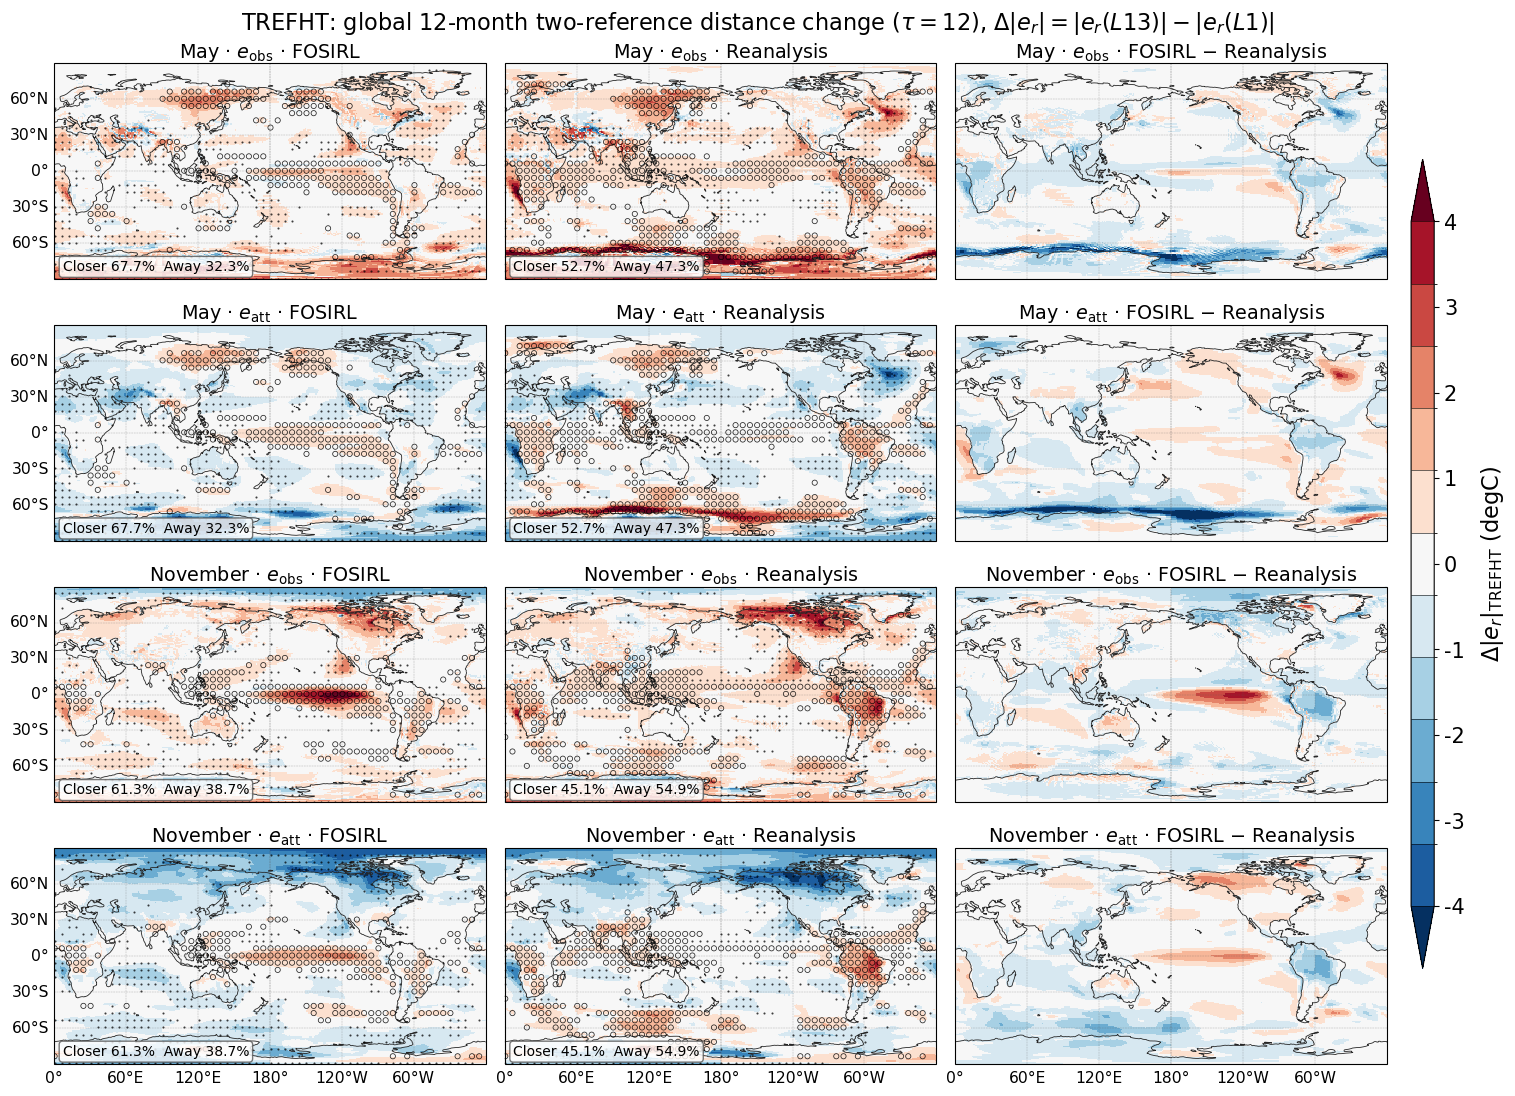

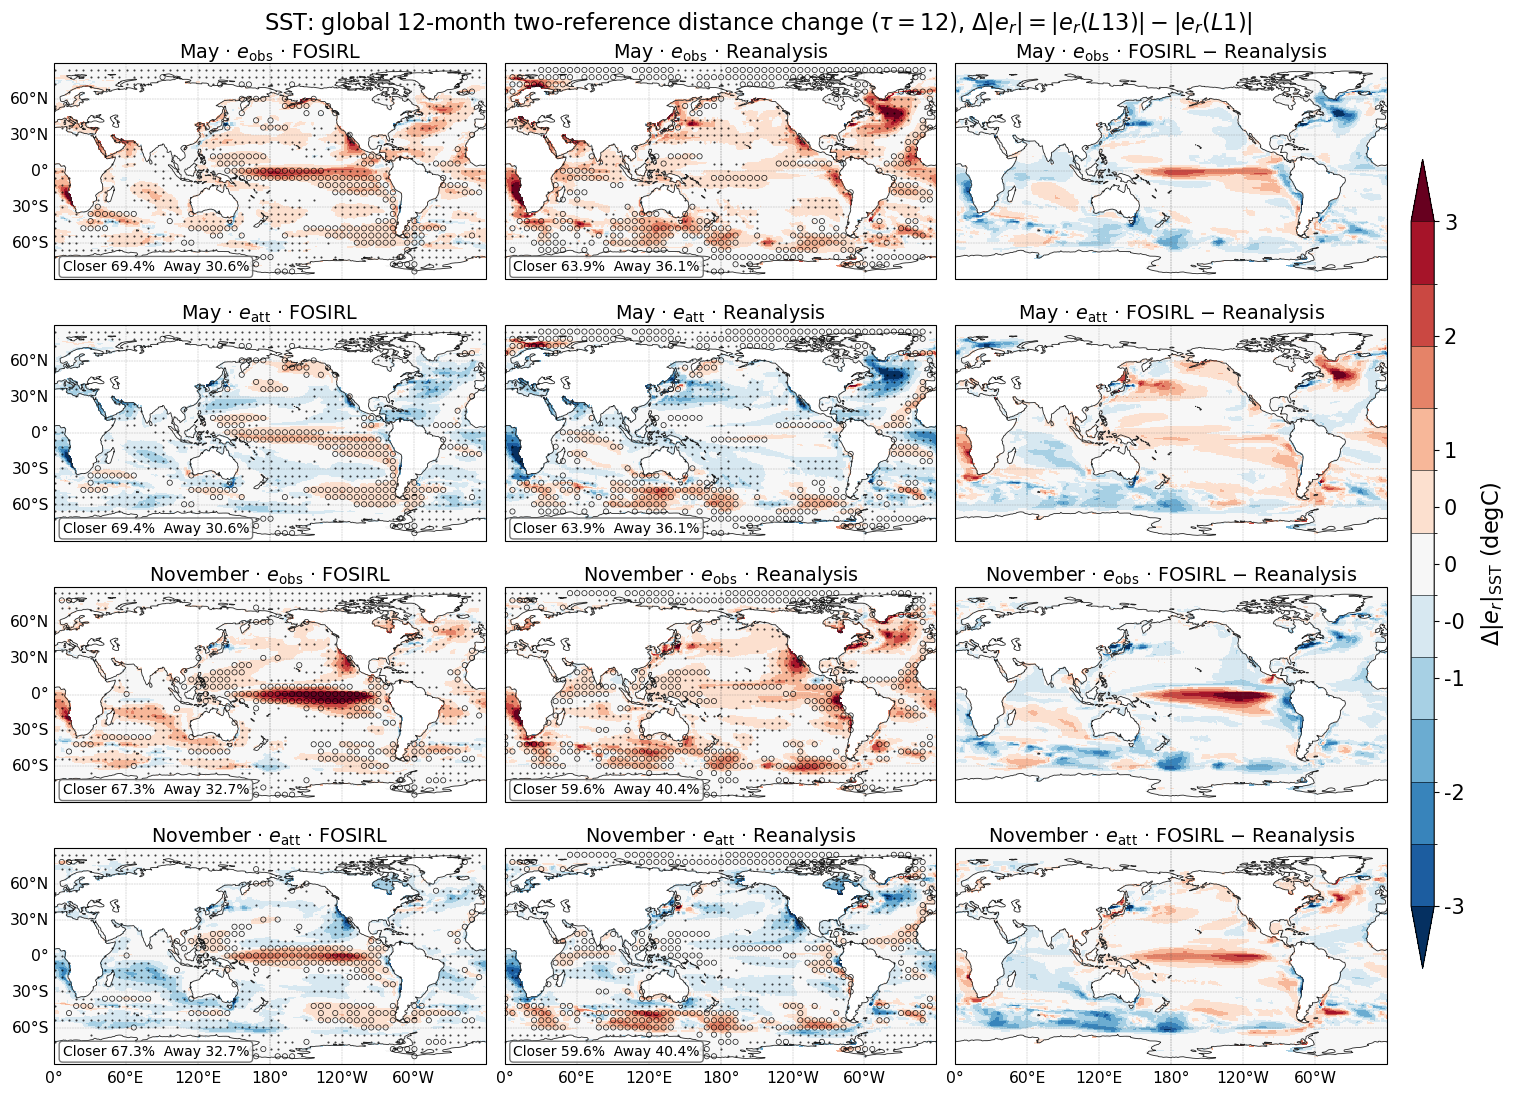

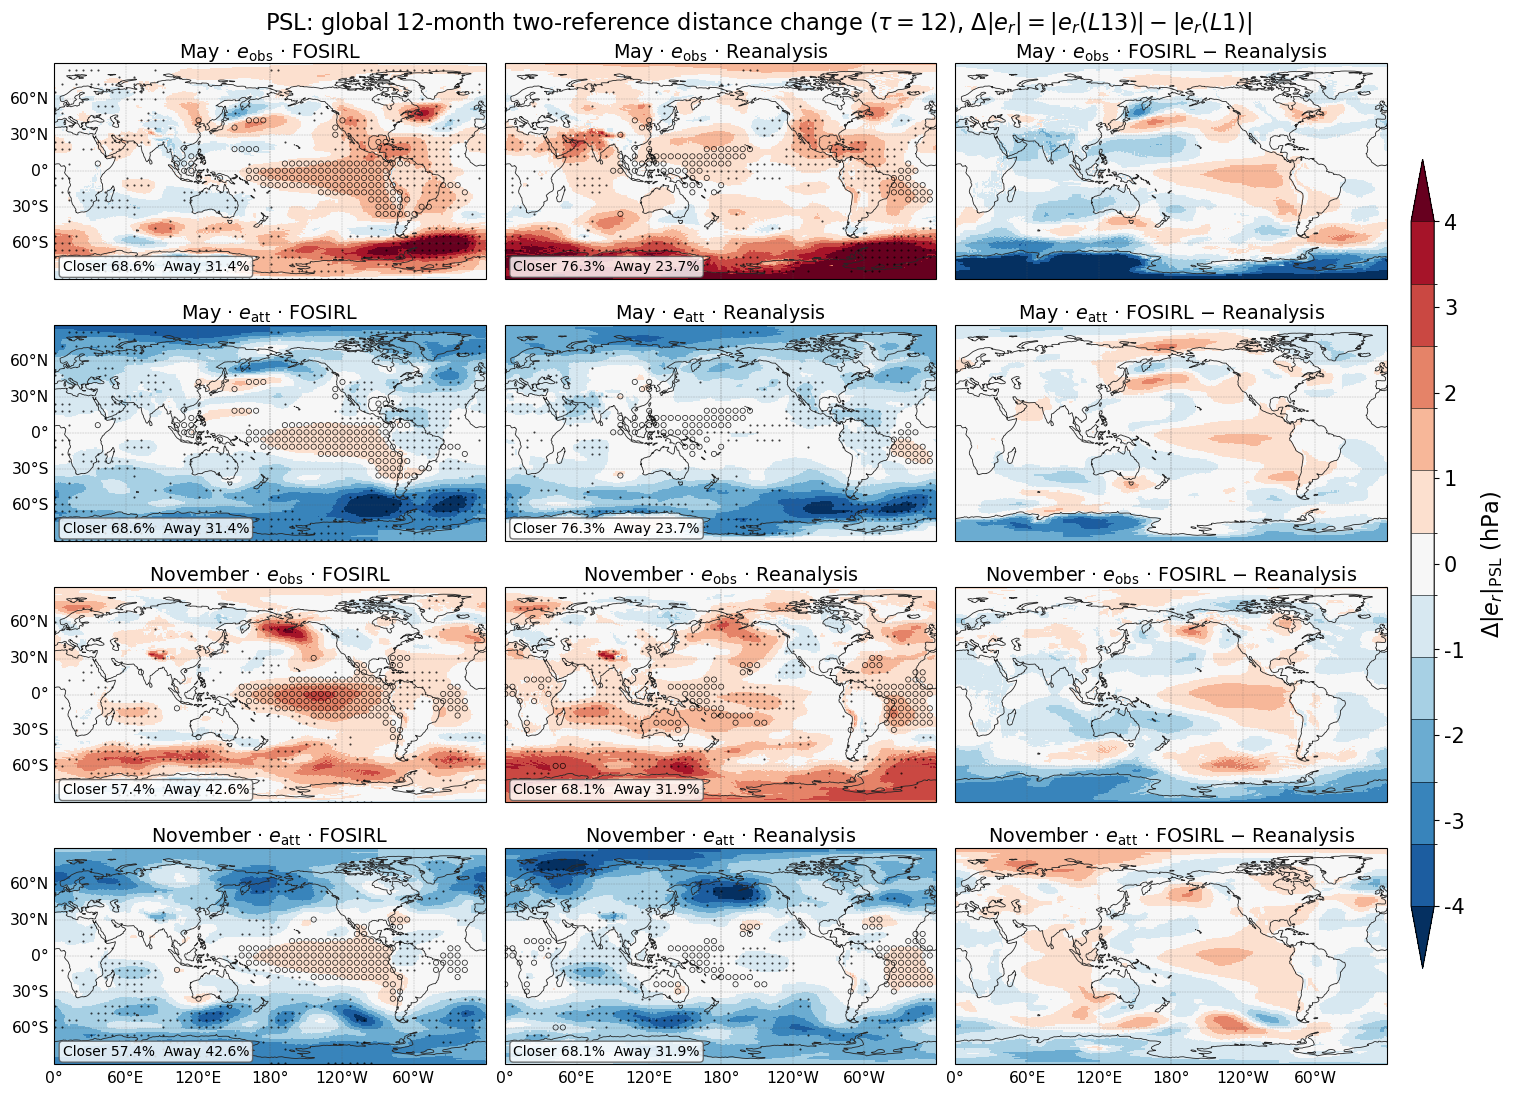

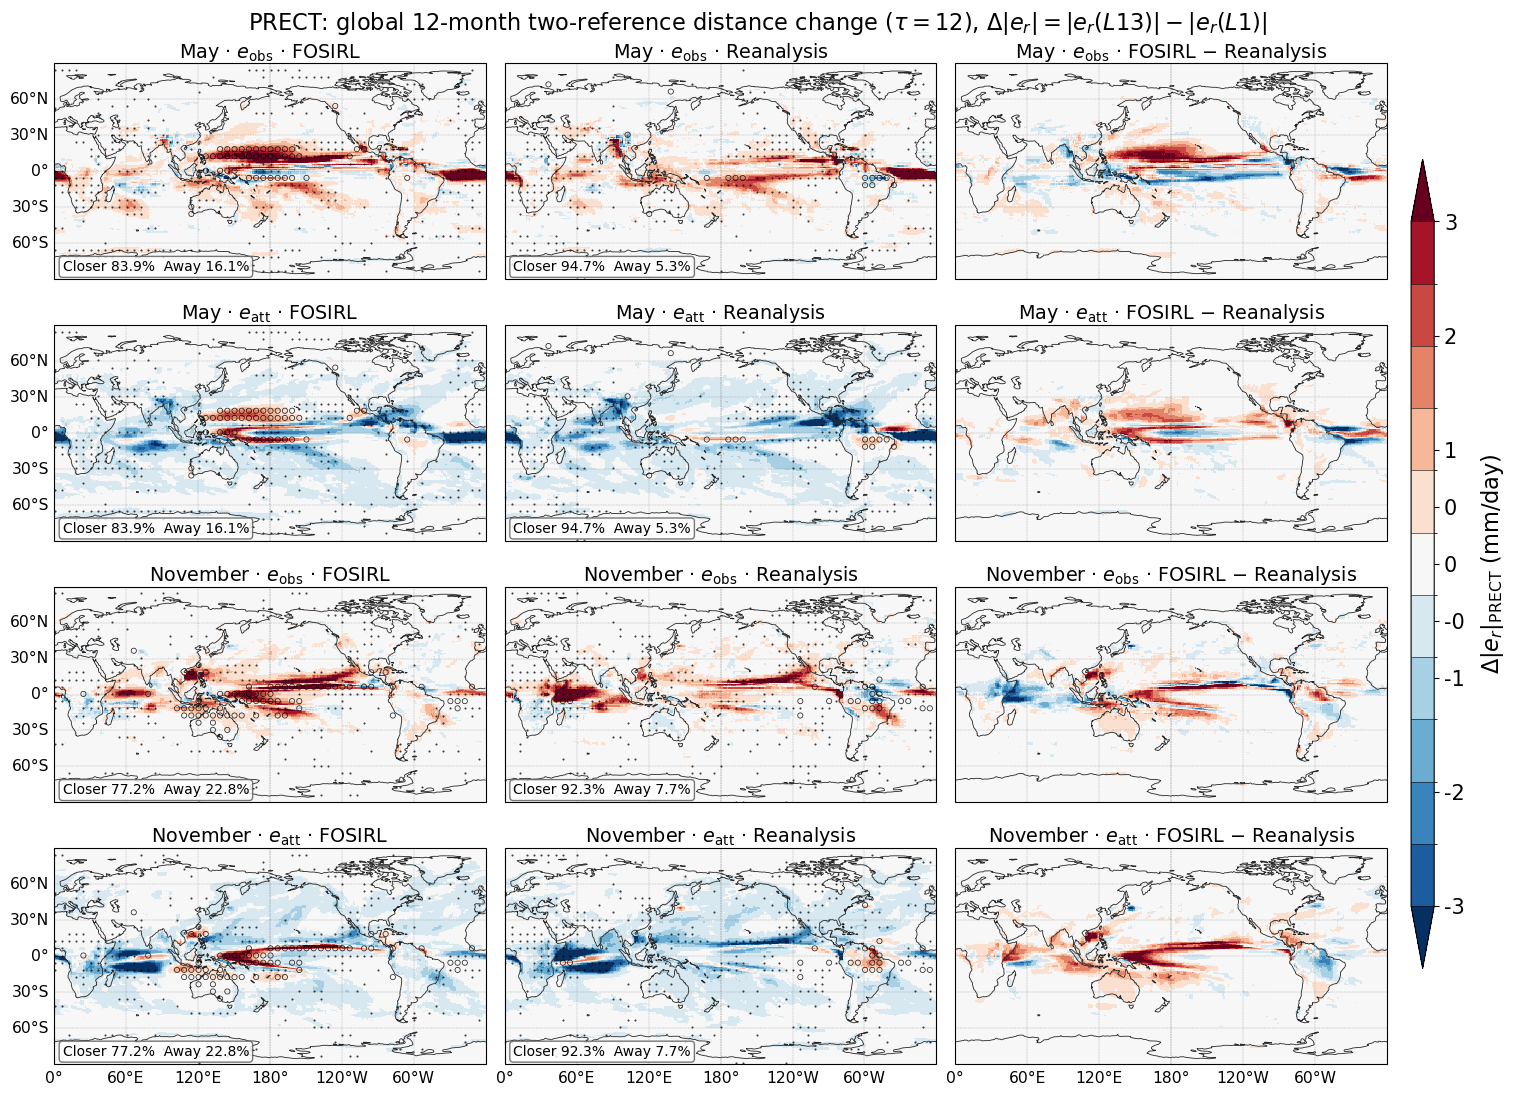

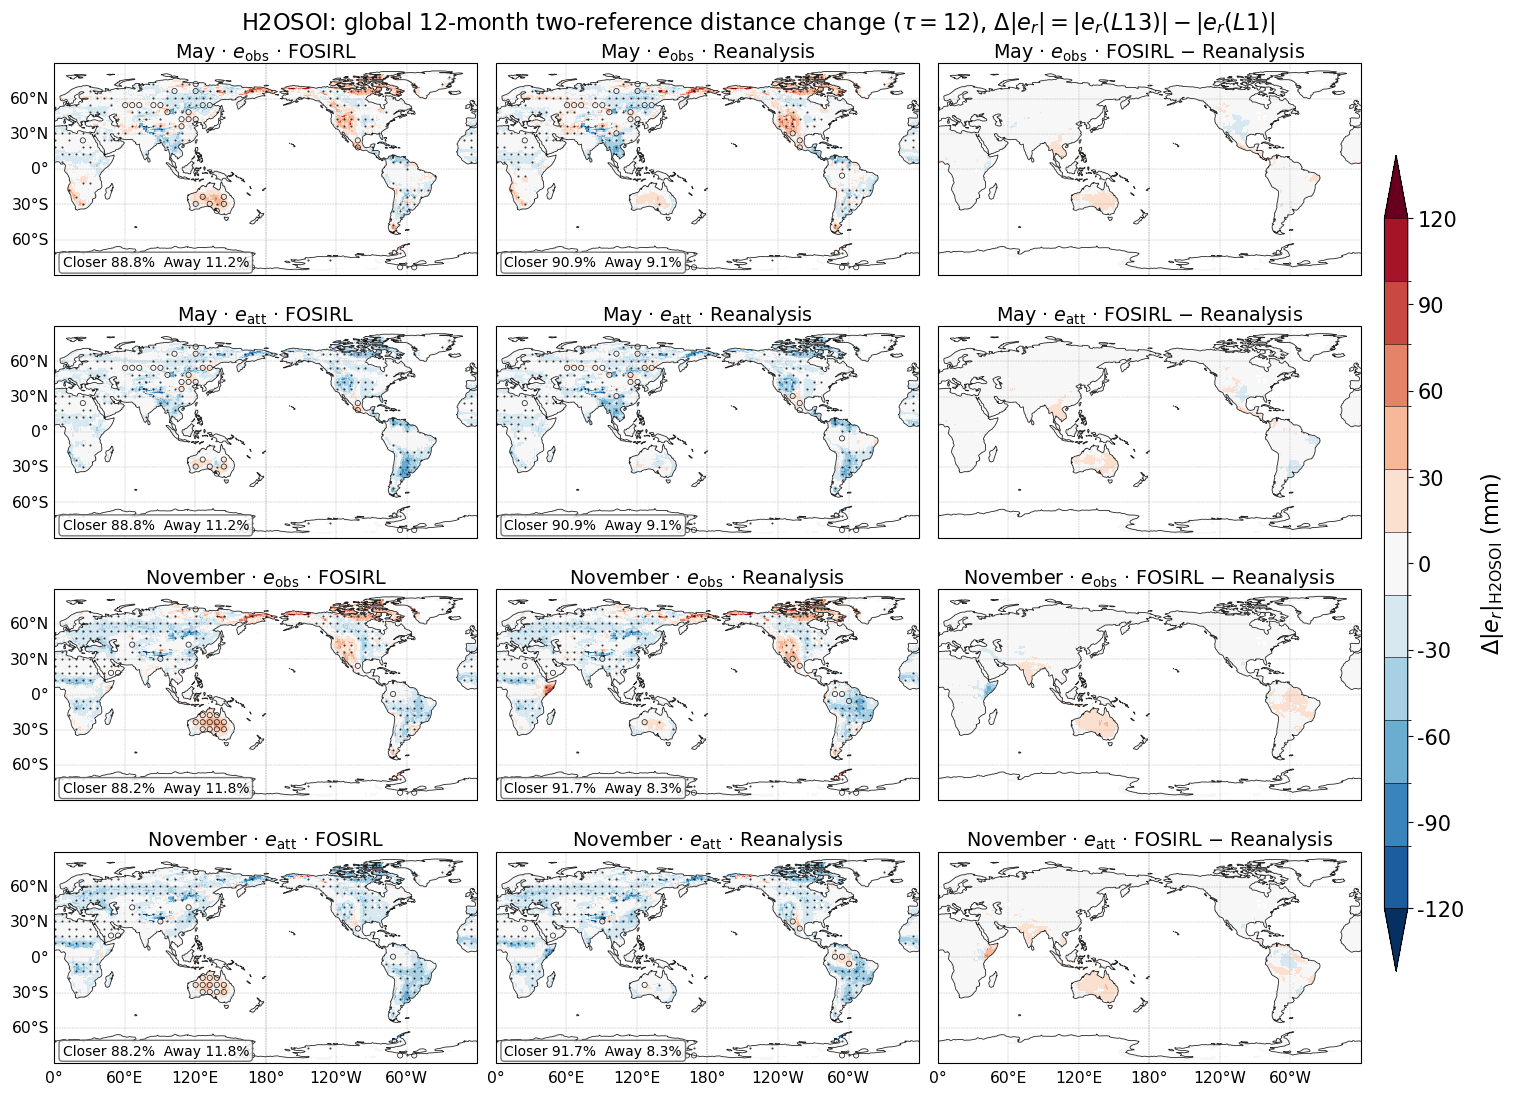

[PosixPath('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_leadtime_drift_two_reference_TREFHT_May_Nov_tau12_L13minusL1_two_reference_absolute_distance_change.png'),
 PosixPath('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_leadtime_drift_two_reference_SST_May_Nov_tau12_L13minusL1_two_reference_absolute_distance_change.png'),
 PosixPath('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_leadtime_drift_two_reference_PSL_May_Nov_tau12_L13minusL1_two_reference_absolute_distance_change.png'),
 PosixPath('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_leadtime_drift_two_reference_PRECT_May_Nov_tau12_L13minusL1_two_reference_absolute_distance_change.png'),
 PosixPath('/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_leadtime_drift_two_reference_H2OSOI_May_Nov_tau12_L13minusL1_two_reference_absolute_distance_change.png')]

In [4]:
def attractor_direction_statistics(regime):
    toward = regime.isin([1, 3])
    away = regime.isin([2, 4])
    classified = toward | away
    latitude_weights = np.cos(np.deg2rad(regime.lat)).clip(min=0.0)
    weights = xr.broadcast(regime, latitude_weights)[1]
    denominator = weights.where(classified).sum(skipna=True)
    if float(denominator) <= 0:
        return np.nan, np.nan
    closer_fraction = float(weights.where(toward).sum(skipna=True) / denominator)
    away_fraction = float(weights.where(away).sum(skipna=True) / denominator)
    return closer_fraction, away_fraction


def overlay_attractor_direction(ax, regime):
    sampled = regime.isel(
        lat=slice(None, None, REGIME_MARKER_STRIDE),
        lon=slice(None, None, REGIME_MARKER_STRIDE),
    )
    longitude, latitude = np.meshgrid(sampled.lon.values, sampled.lat.values)
    values = sampled.values
    closer = np.isin(values, [1, 3])
    away = np.isin(values, [2, 4])
    ax.scatter(
        longitude[closer], latitude[closer], marker='.', s=9,
        color='black', linewidths=0, alpha=0.75, zorder=3,
        transform=DATA_CRS,
    )
    ax.scatter(
        longitude[away], latitude[away], marker='o', s=14,
        facecolors='none', edgecolors='black', linewidths=0.55,
        alpha=0.85, zorder=3,
        transform=DATA_CRS,
    )
    closer_fraction, away_fraction = attractor_direction_statistics(regime)
    if np.isfinite(closer_fraction):
        text = f'Closer {closer_fraction:.1%}  Away {away_fraction:.1%}'
    else:
        text = 'No dominant regime'
    ax.text(
        0.02, 0.025, text, transform=ax.transAxes, ha='left', va='bottom',
        fontsize=FONT_SIZES['information_box'], zorder=4,
        bbox={'boxstyle': 'round,pad=0.25', 'facecolor': 'white',
              'edgecolor': '0.35', 'alpha': 0.82},
    )


figure_paths = []

plot_rows = [
    (init_month, reference)
    for init_month in INIT_MONTHS
    for reference in PLOT_REFERENCE_ROWS
]

for variable in VARIABLES:
    limit = COLORBAR_LIMITS[variable]
    color_boundaries = np.linspace(
        -limit, limit, DISCRETE_COLOR_BINS + 1
    )
    discrete_cmap = plt.get_cmap(
        'RdBu_r', DISCRETE_COLOR_BINS + 2
    ).with_extremes(
        under=COLORBAR_UNDER_COLOR, over=COLORBAR_OVER_COLOR
    )
    color_norm = BoundaryNorm(
        color_boundaries, discrete_cmap.N, extend=COLORBAR_EXTEND
    )

    fig, axes = plt.subplots(
        len(plot_rows),
        len(STRATEGY_COLUMNS),
        figsize=FIGURE_SIZE,
        squeeze=False,
        constrained_layout=True,
        subplot_kw={'projection': MAP_CRS},
    )
    fig.get_layout_engine().set(
        h_pad=0.01, hspace=0.01, w_pad=0.02, wspace=0.02
    )
    image = None
    for row, (init_month, reference) in enumerate(plot_rows):
        for col, strategy in enumerate(STRATEGY_COLUMNS):
            ax = axes[row, col]
            field = distance_change_maps[(reference, variable, init_month, strategy)]
            image = field.plot.pcolormesh(
                ax=ax,
                x='lon',
                y='lat',
                cmap=discrete_cmap,
                norm=color_norm,
                add_colorbar=False,
                transform=DATA_CRS,
            )
            ax.set_global()
            ax.coastlines(resolution='110m', linewidth=0.6, color='0.15')
            gridlines = ax.gridlines(
                crs=DATA_CRS, draw_labels=True, linewidth=0.35,
                color='0.35', alpha=0.45, linestyle='--',
                x_inline=False, y_inline=False,
            )
            gridlines.top_labels = False
            gridlines.right_labels = False
            gridlines.left_labels = col == 0
            gridlines.bottom_labels = row == len(plot_rows) - 1
            gridlines.xlabel_style = {
                'size': FONT_SIZES['geographic_label']
            }
            gridlines.ylabel_style = {
                'size': FONT_SIZES['geographic_label']
            }
            ax.set_title(
                f'{MONTH_NAMES[init_month]} · '
                f'{REFERENCE_ROW_LABELS[reference]} · '
                f'{SOURCE_LABELS[strategy]}',
                pad=2, fontsize=FONT_SIZES['panel_title'],
            )
            if strategy in SOURCES:
                overlay_attractor_direction(
                    ax, regime_maps[(variable, init_month, strategy)]
                )

    units = distance_change_maps[(
        'observation', variable, INIT_MONTHS[0], 'Reanalysis'
    )].attrs.get('units', '')
    colorbar = fig.colorbar(
        image, ax=axes.ravel().tolist(),
        shrink=COLORBAR_SHRINK, fraction=COLORBAR_FRACTION,
        aspect=COLORBAR_ASPECT, pad=COLORBAR_PAD,
        boundaries=color_boundaries,
        ticks=COLORBAR_TICKS[variable],
        spacing='uniform', drawedges=True,
        extend=COLORBAR_EXTEND,
        extendfrac=COLORBAR_EXTEND_FRACTION,
    )
    colorbar.set_label(
        COLORBAR_LABELS[variable].replace('{units}', units),
        fontsize=FONT_SIZES['colorbar_label'], labelpad=10,
    )
    colorbar.ax.tick_params(labelsize=FONT_SIZES['colorbar_tick'])
    colorbar.ax.yaxis.set_major_formatter(
        FormatStrFormatter(COLORBAR_TICK_FORMATS[variable])
    )
    fig.suptitle(
        f"{variable}: global {LEAD_OFFSET}-month two-reference "
        f"distance change ($\\tau={LEAD_OFFSET}$), "
        f"$\\Delta|e_r|=|e_r(L{TARGET_LEAD})|-"
        f"|e_r(L{BASELINE_LEAD})|$",
        fontsize=FONT_SIZES['figure_title'],
    )
    path = FIGURE_ROOT / (
        f'{FIGURE_PREFIX}_{variable}_May_Nov_'
        f'tau{LEAD_OFFSET:02d}_L{TARGET_LEAD}minusL{BASELINE_LEAD}_'
        'two_reference_absolute_distance_change.png'
    )
    fig.savefig(path, dpi=FIGURE_DPI, bbox_inches='tight')
    if SHOW_FIGURES_INLINE:
        display(fig)
    plt.close(fig)
    figure_paths.append(path)

figure_paths

## 4. Validation

In [5]:
assert len(cache_records) == len(VARIABLES) * len(INIT_MONTHS) * len(SOURCES)
assert all(record['path'].is_file() and record['path'].stat().st_size > 0 for record in cache_records)
assert len(plot_rows) == len(INIT_MONTHS) * len(PLOT_REFERENCE_ROWS)
assert len(figure_paths) == len(VARIABLES)
assert all(path.is_file() and path.stat().st_size > 0 for path in figure_paths)
for field in adjustment_maps.values():
    assert field.dims == ('lat', 'lon')
    assert np.isfinite(field.values).any()
for field in distance_change_maps.values():
    assert field.dims == ('lat', 'lon')
    assert np.isfinite(field.values).any()
for regime in regime_maps.values():
    assert regime.dims == ('lat', 'lon')
    finite_codes = regime.values[np.isfinite(regime.values)]
    assert np.isin(finite_codes, [1, 2, 3, 4]).all()
print(
    f'Validated {len(cache_records)} strategy-map caches, '
    f'{len(adjustment_maps)} comparison maps, and '
    f'{len(figure_paths)} global comparison figures.'
)

Validated 20 strategy-map caches, 60 comparison maps, and 5 global comparison figures.
